# Bayesian Approach #

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

data = pd.read_csv('../data/normalized_data.csv')

n_pci = 1008
embedding_dim = 1

pci_embedding = nn.Embedding(n_pci, embedding_dim)

pci_batch = torch.tensor(data['pci'].values, dtype=torch.long)
embedded = pci_embedding(pci_batch) 

data['pci_embedding'] = embedded.detach().numpy()
data.describe()


,lat,lon,distance,rsrp,pci,lat_minmax,lon_minmax,distance_minmax,rsrp_minmax,pci_minmax,lat_meannorm,lon_meannorm,distance_meannorm,rsrp_meannorm,pci_embedding
count,8751.000000,8751.000000,8751.000000,8751.000000,8751.00000,8751.000000,8751.000000,8751.000000,8751.000000,8751.000000,8.751000e+03,8.751000e+03,8.751000e+03,8.751000e+03,8751.000000
mean,51.402957,12.225325,971.497058,-96.671660,292.67718,0.471321,0.321519,0.209298,0.397318,0.107996,-1.191367e-13,8.966593e-14,-1.266651e-16,-3.670041e-16,0.952198
std,0.007265,0.023515,630.722851,10.460354,206.93957,0.174299,0.184387,0.138944,0.163443,0.291464,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.736309
min,51.383310,12.184321,21.408394,-122.100000,216.00000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.704097e+00,-1.743717e+00,-1.506349e+00,-2.430925e+00,-0.994012
25%,51.398577,12.212023,556.504952,-104.000000,216.00000,0.366244,0.217216,0.117878,0.282812,0.000000,-6.028578e-01,-5.656720e-01,-6.579627e-01,-7.005823e-01,0.321943
50%,51.402826,12.220339,772.526881,-97.300000,217.00000,0.468189,0.282423,0.165466,0.387500,0.001408,-1.796829e-02,-2.120287e-01,-3.154637e-01,-6.006867e-02,1.487834
75%,51.405306,12.228229,1233.469290,-90.000000,218.00000,0.527684,0.344286,0.267008,0.501563,0.002817,3.233721e-01,1.234773e-01,4.153524e-01,6.378044e-01,1.487834
max,51.424994,12.311853,4560.819024,-58.100000,926.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.033174e+00,3.679663e+00,5.690807e+00,3.687414e+00,1.519907


c:\Users\arnes\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\arnes\AppData\Local\Temp\ipykernel_189152\4193401299.py:202: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  if param.grad is not None:


Step 0, Loss: 41874.9503, Avg Sigma: 0.9939
Step 100, Loss: 34017.8971, Avg Sigma: 0.9733
Step 200, Loss: 27644.2535, Avg Sigma: 0.9607
Step 300, Loss: 22923.1730, Avg Sigma: 0.8538
Step 400, Loss: 21919.3875, Avg Sigma: 0.8160
Step 500, Loss: 16945.4704, Avg Sigma: 0.7927
Step 600, Loss: 15823.0663, Avg Sigma: 0.7935
Step 700, Loss: 16374.0736, Avg Sigma: 0.7671
Step 800, Loss: 17149.6065, Avg Sigma: 0.7745
Step 900, Loss: 14109.3039, Avg Sigma: 0.7755
Step 1000, Loss: 13085.7983, Avg Sigma: 0.7418
Step 1100, Loss: 13317.6519, Avg Sigma: 0.7453
Step 1200, Loss: 12600.1570, Avg Sigma: 0.7285
Step 1300, Loss: 12076.1630, Avg Sigma: 0.7176
Step 1400, Loss: 11721.5362, Avg Sigma: 0.7109
Step 1500, Loss: 11812.0099, Avg Sigma: 0.6979
Step 1600, Loss: 12101.0194, Avg Sigma: 0.7082
Step 1700, Loss: 11326.9163, Avg Sigma: 0.6988
Step 1800, Loss: 11198.7069, Avg Sigma: 0.7008
Step 1900, Loss: 11432.6568, Avg Sigma: 0.6814
Step 2000, Loss: 11833.9345, Avg Sigma: 0.6753
Step 2100, Loss: 11283.59

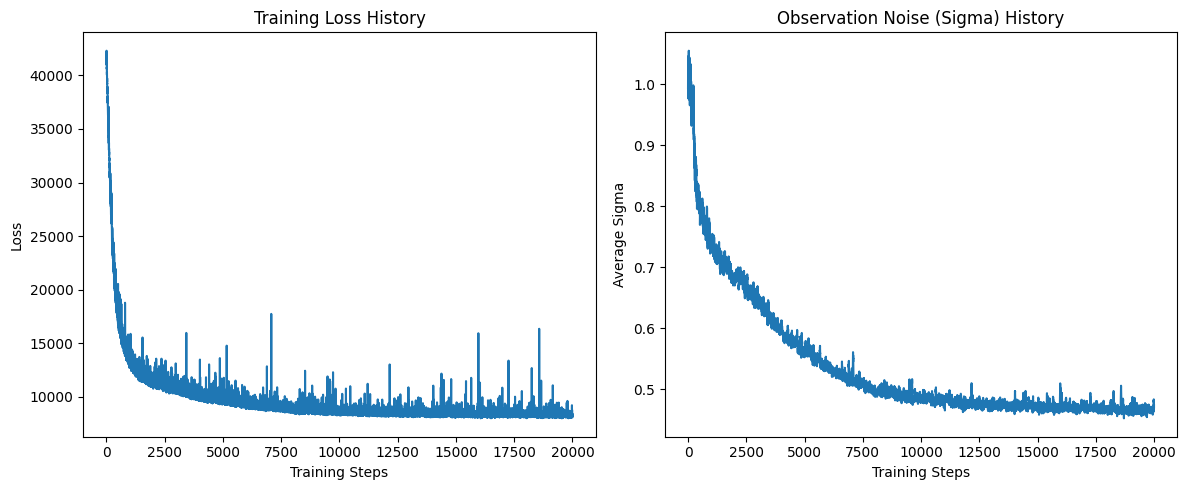

In [ ]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt

class ScaledTraceELBO(Trace_ELBO):
    def __init__(self, kl_factor=1.0, n_layers=1, **kwargs):
        super().__init__(**kwargs)
        self.kl_factor = kl_factor
        self.n_layers = n_layers

    def loss(self, model, guide, *args, **kwargs):
        _, (log_likelihood, kl) = self._differentiable_loss_particle(
            model, guide, *args, **kwargs
        )
        scaled_kl = kl * self.kl_factor * self.n_layers

        return -(log_likelihood - scaled_kl)



# Bayesian Neural Network with heteroscedastic likelihood
class BNN(pyro.nn.PyroModule):
    def __init__(self, input_dim=None, hidden_dims=None, output_dim=None, kl_factor=1.0, A_prior_scale=0.5, sigma_prior_scale=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims if hidden_dims is not None else []
        self.output_dim = output_dim
        self.kl_factor = kl_factor
        self.A_prior_scale = A_prior_scale
        self.sigma_prior_scale = sigma_prior_scale

        # Build the sequence of layer dimensions for mean prediction
        layer_dims = [input_dim] + self.hidden_dims + [output_dim]
        self.n_layers = len(layer_dims) - 1

        # Sigma prediction network
        sigma_hidden_dims = [5,5]
        sigma_layer_dims = [input_dim] + sigma_hidden_dims + [output_dim]
        self.sigma_n_layers = len(sigma_layer_dims) - 1

        
        self.layer_names = [f"fc{i+1}" for i in range(self.n_layers)]
        self.sigma_layer_names = [f"sigma_fc{i+1}" for i in range(self.sigma_n_layers)]

        # Mean prediction
        self.linears = torch.nn.ModuleList([
            torch.nn.Linear(layer_dims[i], layer_dims[i+1])
            for i in range(self.n_layers)
        ])
        # Sigma prediction
        self.sigma_linears = torch.nn.ModuleList([
            torch.nn.Linear(sigma_layer_dims[i], sigma_layer_dims[i+1])
            for i in range(self.sigma_n_layers)
        ])
        self.relu = torch.nn.ReLU()
        self.min_sigma = 1e-6

    def model(self, x, y=None):
        weights = []
        biases = []
        sigma_weights = []
        sigma_biases = []
        # Priors for mean prediction
        for i in range(self.n_layers):
            w_name = f"{self.layer_names[i]}_weight"
            b_name = f"{self.layer_names[i]}_bias"
            w_shape = (self.linears[i].in_features, self.linears[i].out_features)
            b_shape = (self.linears[i].out_features,)
            weights.append(pyro.sample(w_name, dist.Normal(torch.zeros(w_shape), self.A_prior_scale).to_event(2)))
            biases.append(pyro.sample(b_name, dist.Normal(torch.zeros(b_shape), self.A_prior_scale).to_event(1)))

        # Priors for sigma prediction
        for i in range(self.sigma_n_layers):
            w_name = f"{self.sigma_layer_names[i]}_weight"
            b_name = f"{self.sigma_layer_names[i]}_bias"
            w_shape = (self.sigma_linears[i].in_features, self.sigma_linears[i].out_features)
            b_shape = (self.sigma_linears[i].out_features,)
            sigma_weights.append(pyro.sample(w_name, dist.Normal(torch.zeros(w_shape), self.sigma_prior_scale).to_event(2)))
            sigma_biases.append(pyro.sample(b_name, dist.Normal(torch.zeros(b_shape), self.sigma_prior_scale).to_event(1)))

        with pyro.plate("data", x.shape[0]):
            # Mean prediction
            h = x
            for i in range(self.n_layers - 1):
                h = self.relu(torch.matmul(h, weights[i]) + biases[i])
            mu = torch.matmul(h, weights[-1]) + biases[-1]
            mu = mu.squeeze(-1)

            # Sigma prediction
            h_sigma = x
            for i in range(self.sigma_n_layers - 1):
                h_sigma = self.relu(torch.matmul(h_sigma, sigma_weights[i]) + sigma_biases[i])
            sigma_log = torch.matmul(h_sigma, sigma_weights[-1]) + sigma_biases[-1]
            sigma = torch.exp(sigma_log.squeeze(-1)) + self.min_sigma

            return pyro.sample("obs", dist.Normal(mu, sigma), obs=y)

    def guide(self, x, y=None):
        weights_loc = []
        weights_scale = []
        biases_loc = []
        biases_scale = []
        sigma_weights_loc = []
        sigma_weights_scale = []
        sigma_biases_loc = []
        sigma_biases_scale = []
        # Variational parameters for mean prediction
        for i in range(self.n_layers):
            w_name = f"{self.layer_names[i]}_weight"
            b_name = f"{self.layer_names[i]}_bias"
            w_shape = (self.linears[i].in_features, self.linears[i].out_features)
            b_shape = (self.linears[i].out_features,)
            w_loc = pyro.param(f"{w_name}_loc", torch.zeros(w_shape))
            w_scale = pyro.param(f"{w_name}_scale", torch.ones(w_shape) * 0.1, constraint=dist.constraints.positive)
            b_loc = pyro.param(f"{b_name}_loc", torch.zeros(b_shape))
            b_scale = pyro.param(f"{b_name}_scale", torch.ones(b_shape) * 0.1, constraint=dist.constraints.positive)
            pyro.sample(w_name, dist.Normal(w_loc, w_scale).to_event(2))
            pyro.sample(b_name, dist.Normal(b_loc, b_scale).to_event(1))

        # Variational parameters for sigma prediction
        for i in range(self.sigma_n_layers):
            w_name = f"{self.sigma_layer_names[i]}_weight"
            b_name = f"{self.sigma_layer_names[i]}_bias"
            w_shape = (self.sigma_linears[i].in_features, self.sigma_linears[i].out_features)
            b_shape = (self.sigma_linears[i].out_features,)
            w_loc = pyro.param(f"{w_name}_loc", torch.zeros(w_shape))
            w_scale = pyro.param(f"{w_name}_scale", torch.ones(w_shape) * 0.05, constraint=dist.constraints.positive)
            b_loc = pyro.param(f"{b_name}_loc", torch.zeros(b_shape))
            b_scale = pyro.param(f"{b_name}_scale", torch.ones(b_shape) * 0.05, constraint=dist.constraints.positive)
            pyro.sample(w_name, dist.Normal(w_loc, w_scale).to_event(2))
            pyro.sample(b_name, dist.Normal(b_loc, b_scale).to_event(1))

    def forward(self, x, n_samples=100):
        preds = []
        sigmas = []
        for _ in range(n_samples):
            weights = []
            biases = []
            sigma_weights = []
            sigma_biases = []
            for i in range(self.n_layers):
                w_name = f"{self.layer_names[i]}_weight"
                b_name = f"{self.layer_names[i]}_bias"
                w_loc = pyro.param(f"{w_name}_loc")
                w_scale = pyro.param(f"{w_name}_scale")
                b_loc = pyro.param(f"{b_name}_loc")
                b_scale = pyro.param(f"{b_name}_scale")
                weights.append(pyro.sample(w_name, dist.Normal(w_loc, w_scale).to_event(2)))
                biases.append(pyro.sample(b_name, dist.Normal(b_loc, b_scale).to_event(1)))

            for i in range(self.sigma_n_layers):
                sw_name = f"{self.sigma_layer_names[i]}_weight"
                sb_name = f"{self.sigma_layer_names[i]}_bias"
                sw_loc = pyro.param(f"{sw_name}_loc")
                sw_scale = pyro.param(f"{sw_name}_scale")
                sb_loc = pyro.param(f"{sb_name}_loc")
                sb_scale = pyro.param(f"{sb_name}_scale")
                sigma_weights.append(pyro.sample(sw_name, dist.Normal(sw_loc, sw_scale).to_event(2)))
                sigma_biases.append(pyro.sample(sb_name, dist.Normal(sb_loc, sb_scale).to_event(1)))

            # Mean prediction
            h = x
            for i in range(self.n_layers - 1):
                h = self.relu(torch.matmul(h, weights[i]) + biases[i])
            mu = torch.matmul(h, weights[-1]) + biases[-1]
            preds.append(mu.squeeze(-1))

            # Sigma prediction
            h_sigma = x
            for i in range(self.sigma_n_layers - 1):
                h_sigma = self.relu(torch.matmul(h_sigma, sigma_weights[i]) + sigma_biases[i])
            sigma_log = torch.matmul(h_sigma, sigma_weights[-1]) + sigma_biases[-1]
            sigmas.append(torch.exp(sigma_log.squeeze(-1)) + self.min_sigma)

        preds = torch.stack(preds)
        sigmas = torch.stack(sigmas)
        mean_pred = preds.mean(0)
        std_pred = preds.std(0)
        mean_sigma = sigmas.mean(0)
        return mean_pred, std_pred, mean_sigma

# Training function
def train_bnn(model, x_train, y_train, num_steps=1000):
    optimizer = Adam({"lr": 0.005})
    svi = SVI(model.model, model.guide, optimizer, loss=ScaledTraceELBO(kl_factor=model.kl_factor, n_layers=model.n_layers))
    loss_history = []
    sigma_history = []

    for step in range(num_steps):
        loss = svi.step(x_train, y_train)
        loss_history.append(loss)

        with torch.no_grad():
            _, _, mean_sigma = model.forward(x_train, n_samples=10)
            avg_sigma = mean_sigma.mean().item()
            sigma_history.append(avg_sigma)

        for param in pyro.get_param_store().values():
            if param.grad is not None:
                torch.nn.utils.clip_grad_norm_([param], max_norm=1.0)

        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss:.4f}, Avg Sigma: {avg_sigma:.4f}")

    return loss_history, sigma_history

if __name__ == "__main__":
    torch.manual_seed(42)
    
    x_train = torch.tensor(data[['lat_meannorm', 'lon_meannorm', 'distance_meannorm', 'pci_embedding']].values, dtype=torch.float32)
    y_train = torch.tensor(data['rsrp_meannorm'].values, dtype=torch.float32)

    # Initialize
    kl_factor = 1.0
    A_prior_scale = 0.5
    sigma_prior_scale = 0.1
    bnn = BNN(input_dim=4, hidden_dims=[200, 100, 50], output_dim=1, kl_factor=kl_factor, A_prior_scale=A_prior_scale, sigma_prior_scale=sigma_prior_scale)
    loss_history, sigma_history = train_bnn(bnn, x_train, y_train, num_steps=20000)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(loss_history)
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss History')
    ax2.plot(sigma_history)
    ax2.set_xlabel('Training Steps')
    ax2.set_ylabel('Average Sigma')
    ax2.set_title('Observation Noise (Sigma) History')
    plt.tight_layout()
    plt.show()

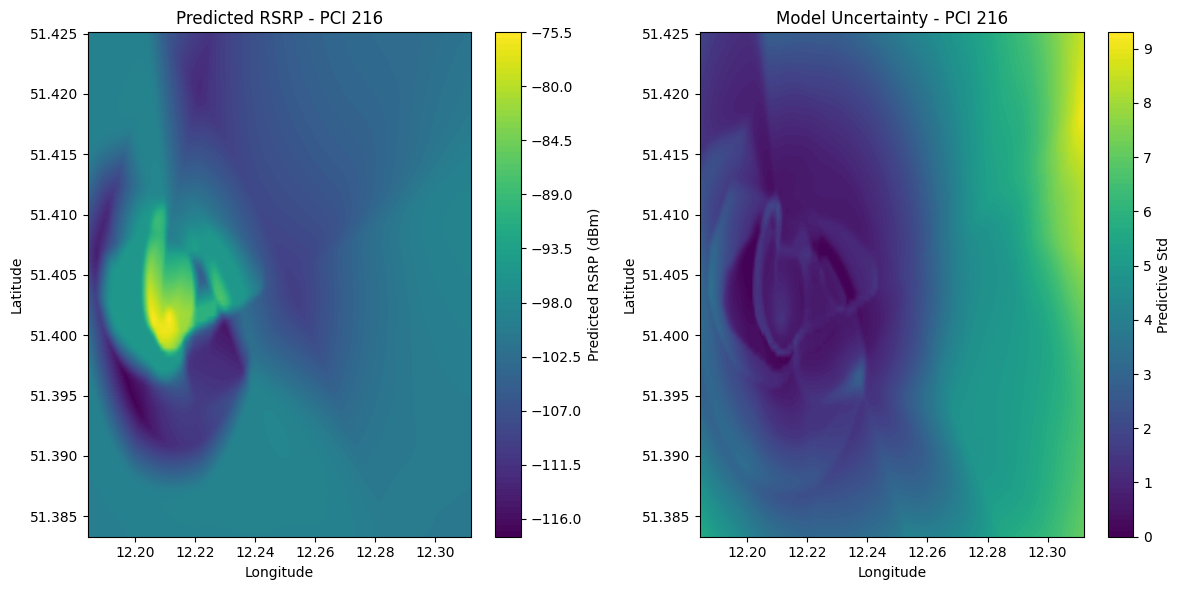

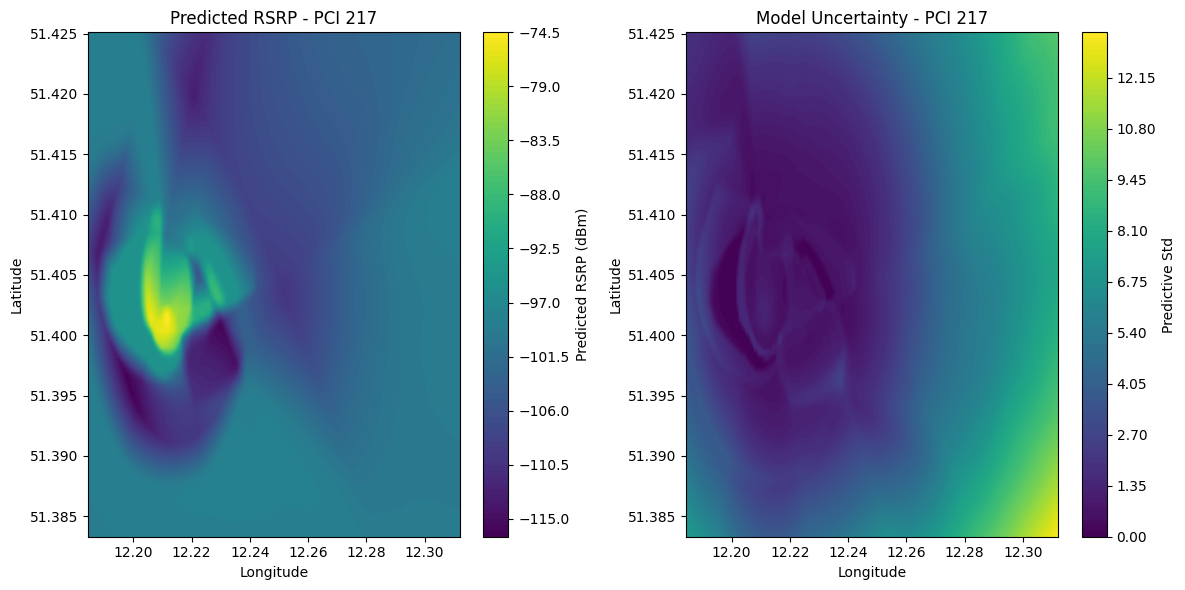

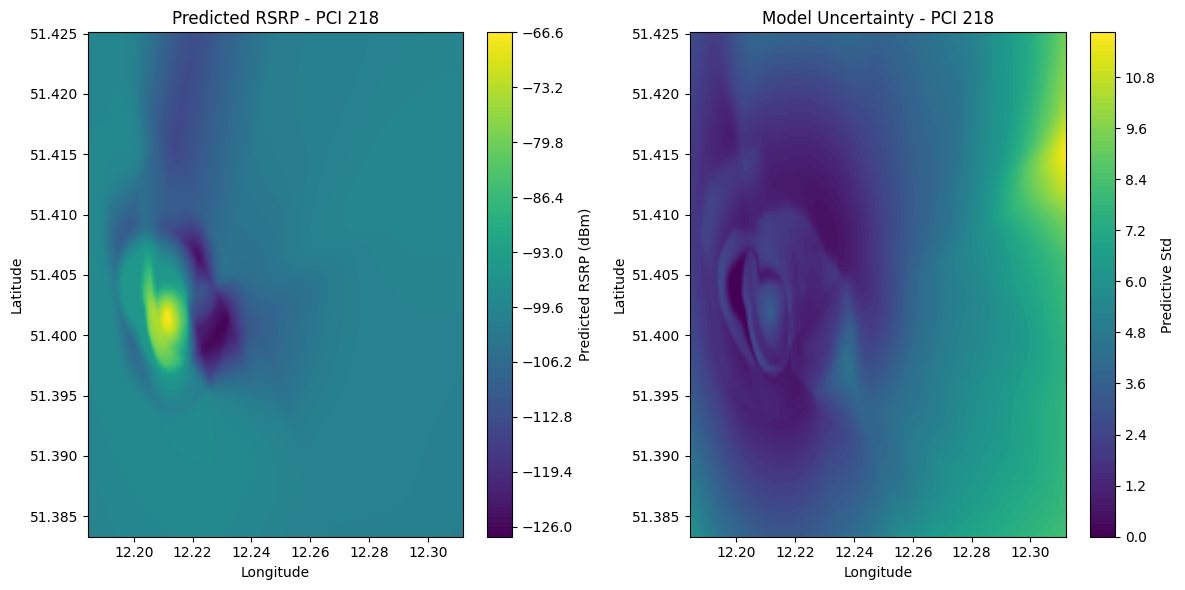

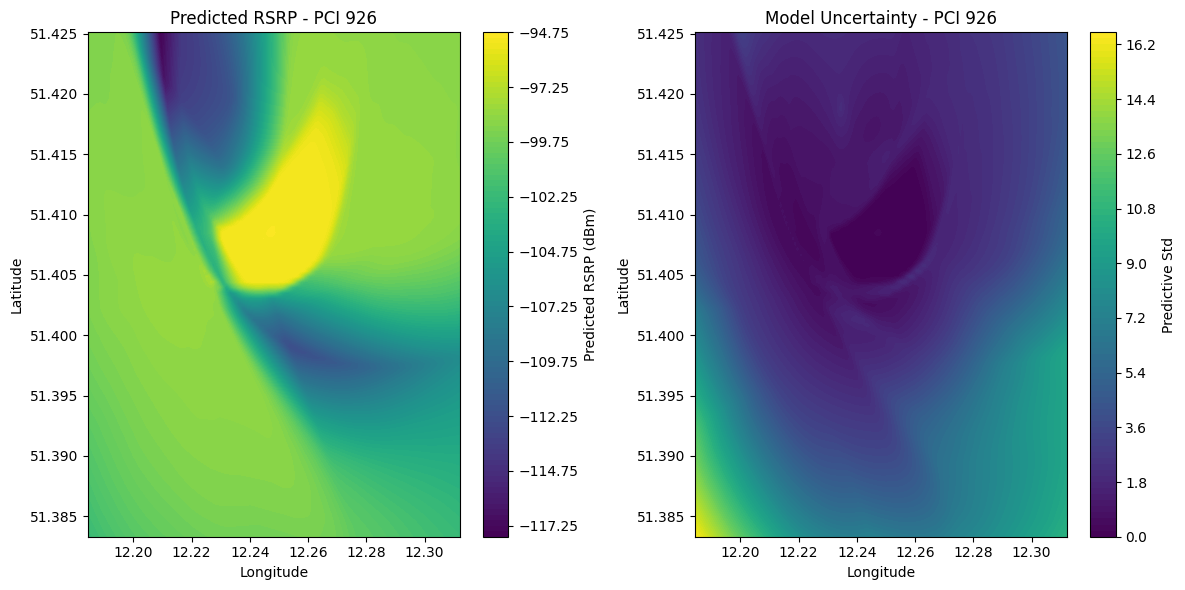

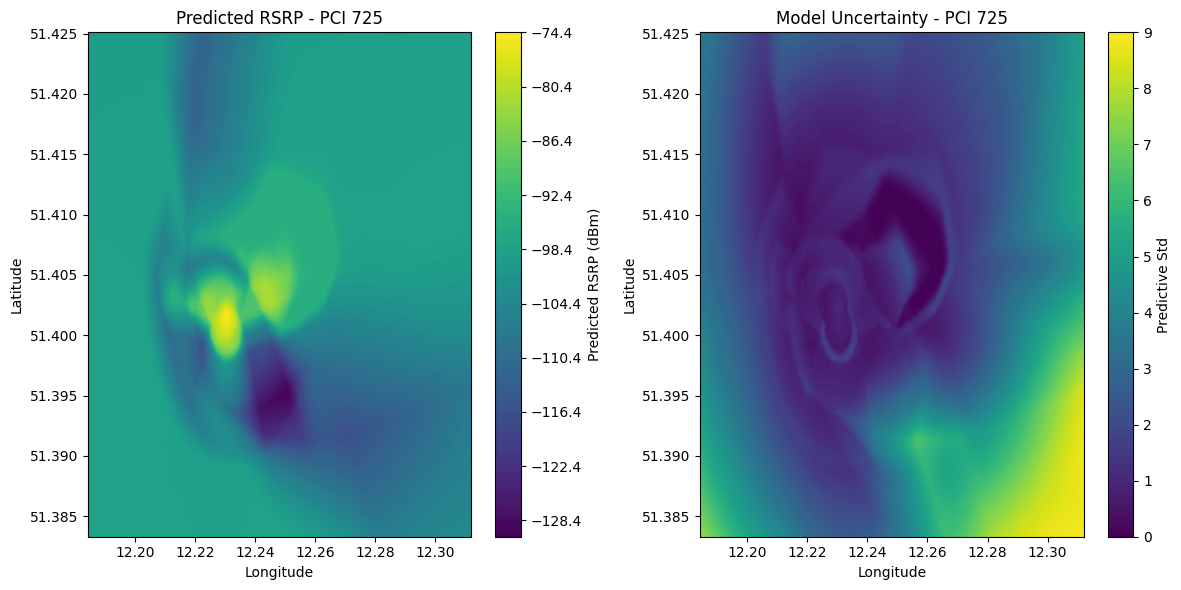

Saved predictions and input features to ../data/predicted_rsrp_grid_bnn.csv


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Geod
import os
import pandas as pd

celltowerData = [
    {
        'lat': 51.401703,
        'lon': 12.211532,
        'pci_angles': [
            {
                'pci': 216
            },
            {
                'pci': 217
            },
            {
                'pci': 218
            }
        ]
    },
    {
        'lat': 51.418999, 
        'lon': 12.234410,
        'pci_angles': [
            {
                'pci': 926
            }
        ]

    },
    {
        'lat': 51.402023, 
        'lon': 12.230574,
        'pci_angles': [
            {
                'pci': 725
            }
        ]
    }
]

# Mean and std values for normalization
lat_mean, lat_std = data["lat"].mean(), data["lat"].std()
lon_mean, lon_std = data["lon"].mean(), data["lon"].std()
dist_mean, dist_std = data["distance"].mean(), data["distance"].std()
rsrp_mean, rsrp_std = data["rsrp"].mean(), data["rsrp"].std()


geod = Geod(ellps='WGS84')
spacing_m = 50

# Bounding Box
lat_min, lat_max = np.min(data["lat"]), np.max(data["lat"])
lon_min, lon_max = np.min(data["lon"]), np.max(data["lon"])

# Prepare base lat/lon grid
lat_points = [lat_min]
while lat_points[-1] < lat_max:
    fwd = geod.fwd(lon_min, lat_points[-1], 0, spacing_m)
    lat_points.append(fwd[1])
lat_points = np.array(lat_points)

lon_points = [lon_min]
while lon_points[-1] < lon_max:
    fwd = geod.fwd(lon_points[-1], lat_min, 90, spacing_m)
    lon_points.append(fwd[0])
lon_points = np.array(lon_points)

mesh_lat, mesh_lon = np.meshgrid(lat_points, lon_points, indexing='ij')
grid_lat = mesh_lat.ravel()
grid_lon = mesh_lon.ravel()

# Loop over all PCIs in celltowerData
all_results = []

for bs in celltowerData:
    bs_lat = bs['lat']
    bs_lon = bs['lon']
    
    for pci_entry in bs['pci_angles']:
        pci_value = pci_entry['pci']

        # Distance from grid points to base station
        _, _, distances = geod.inv(
            np.full_like(grid_lon, bs_lon),
            np.full_like(grid_lat, bs_lat),
            grid_lon,
            grid_lat
        )

        # Normalize lat/lon/dist for model input only
        lat_meannorm = (grid_lat - lat_mean) / lat_std
        lon_meannorm = (grid_lon - lon_mean) / lon_std
        dist_meannorm = (distances - dist_mean) / dist_std

        # PCI embedding instead of normalization
        pci_tensor = torch.tensor([pci_value] * len(grid_lat), dtype=torch.long)
        pci_emb = pci_embedding(pci_tensor) 

        # Stack input features
        numeric_features = torch.tensor(
            np.stack([lat_meannorm, lon_meannorm, dist_meannorm], axis=1),
            dtype=torch.float32
        )

        # Concatenate numeric features with PCI embedding
        input_tensor = torch.cat([numeric_features, pci_emb], dim=1)

        # Predict
        bnn.eval()
        with torch.no_grad():
            rsrp_meannorm, std, _ = bnn(input_tensor)

        # Reverse normalization for RSRP
        rsrp_pred = rsrp_meannorm * rsrp_std + rsrp_mean
        std_pred = std * rsrp_std

        # Save only original input and predicted data for this PCI
        pci_results = {
            "lat": grid_lat,
            "lon": grid_lon,
            "distance": distances,
            "pci": [pci_value] * len(grid_lat),
            "mean_rsrp": rsrp_pred.cpu().numpy(),
            "std_rsrp": std_pred.cpu().numpy()
        }
        all_results.append(pci_results)

        # --- Plot ---
        rsrp_grid = rsrp_pred.reshape(mesh_lat.shape)
        std_grid = std_pred.reshape(mesh_lat.shape)
        plt.figure(figsize=(12, 6))

        # RSRP plot
        plt.subplot(1, 2, 1)
        plt.contourf(mesh_lon, mesh_lat, rsrp_grid, levels=100)
        plt.colorbar(label="Predicted RSRP (dBm)")
        plt.title(f"Predicted RSRP - PCI {pci_value}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        # STD plot
        plt.subplot(1, 2, 2)
        plt.contourf(mesh_lon, mesh_lat, std_grid, levels=100)
        plt.colorbar(label="Predictive Std")
        plt.title(f"Model Uncertainty - PCI {pci_value}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.tight_layout()
        plt.show()

# Combine all results into a single DataFrame
df_list = []
for res in all_results:
    df = pd.DataFrame(res)
    df_list.append(df)
full_pred_df = pd.concat(df_list, ignore_index=True)

# Ensure the directory exists
os.makedirs('../data', exist_ok=True)

# Save to CSV
full_pred_df.to_csv('../data/predicted_rsrp_grid_bnn.csv', index=False)
print("Saved predictions and input features to ../data/predicted_rsrp_grid_bnn.csv")


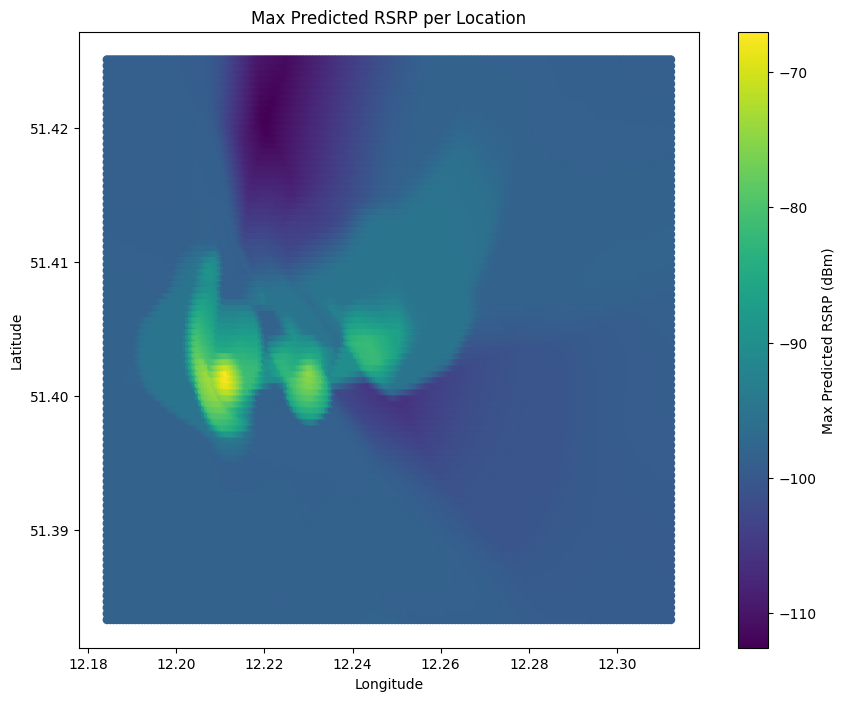

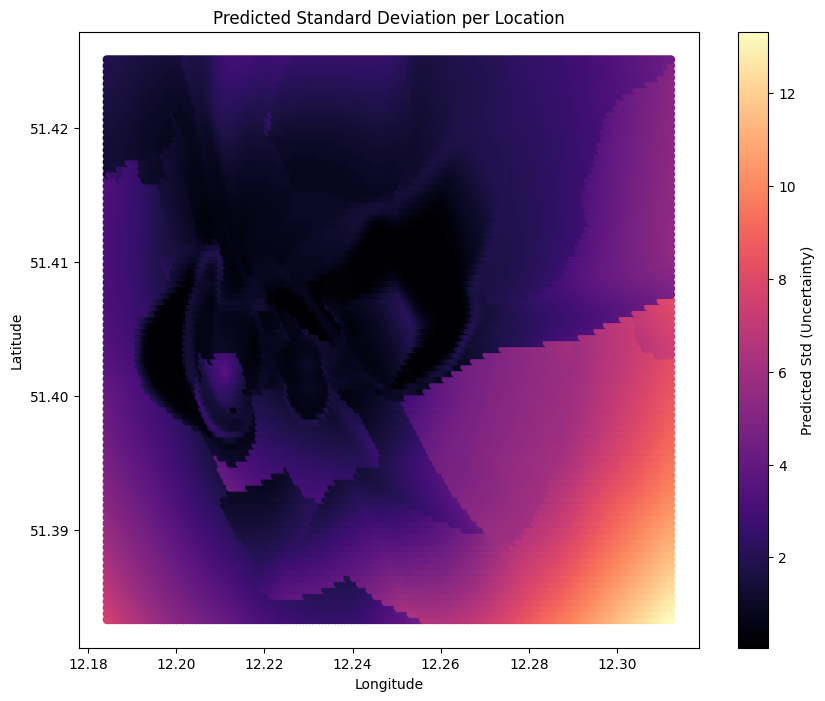

In [4]:
import pandas as pd

# Load the CSV file
csv_path = r"../data/predicted_rsrp_grid_bnn.csv"
df_grid = pd.read_csv(csv_path)

# Group by lat/lon and keep the row with the highest mean_rsrp
df_max_rsrp = df_grid.loc[df_grid.groupby(['lat', 'lon'])['mean_rsrp'].idxmax()]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sc = plt.scatter(df_max_rsrp['lon'], df_max_rsrp['lat'], c=df_max_rsrp['mean_rsrp'], cmap='viridis', s=30)
plt.colorbar(sc, label='Max Predicted RSRP (dBm)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Max Predicted RSRP per Location')
plt.show()

plt.figure(figsize=(10, 8))
sc_std = plt.scatter(df_max_rsrp['lon'], df_max_rsrp['lat'], c=df_max_rsrp['std_rsrp'], cmap='magma', s=30)
plt.colorbar(sc_std, label='Predicted Std (Uncertainty)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Standard Deviation per Location')
plt.show()

df_max_rsrp.to_csv('../data/max_predicted_rsrp.csv', index=False)